In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Data Loading KELP



Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3',
       'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2',
       'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss'],
      dtype='object')


/var/folders/cf/56rkkkts0hn_0lmp9_4p59dm0000gn/T/ipykernel_53027/2788926574.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  k['smoothed'] = k['mid_price'].rolling(window=300).mean()
/var/folders/cf/56rkkkts0hn_0lmp9_4p59dm0000gn/T/ipykernel_53027/2788926574.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  k1['smoothed'] = k1['mid_price'].rolling(window=300).mean()
/var/folders/cf/56rkkkts0hn_0lmp9_4p59dm0000gn/T/ipykernel_53027/2788926574.py:20: SettingWithCopyWarning: 
A value is trying to be set 

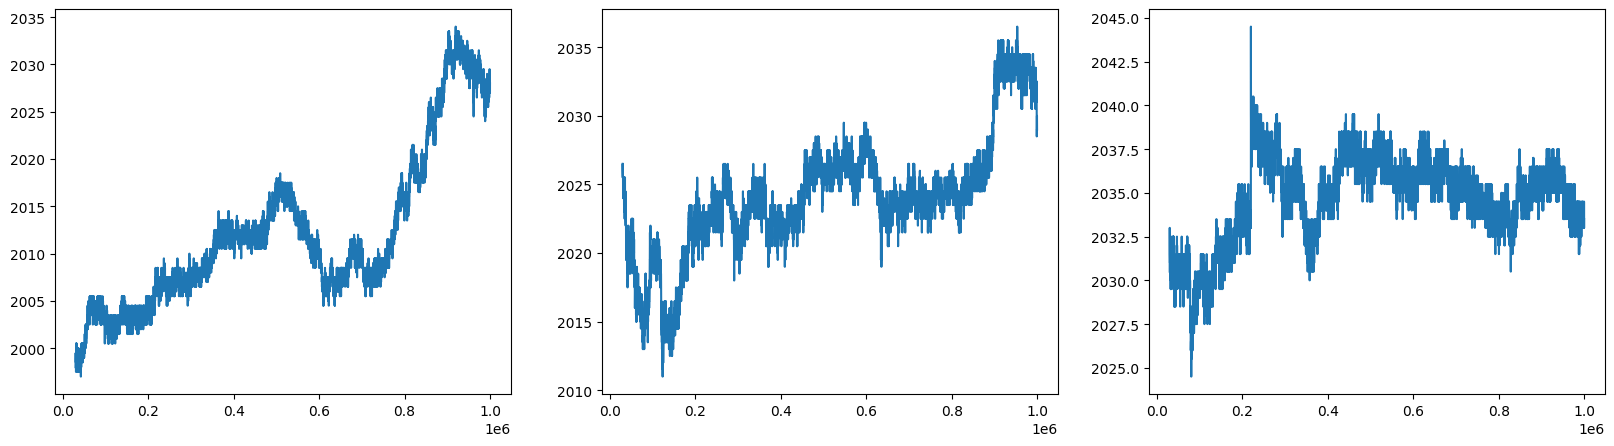

In [3]:
d1 = pd.read_csv("data/prices_round_1_day_-2.csv" , delimiter=";")
d2 = pd.read_csv("data/prices_round_1_day_-1.csv" , delimiter=";")
d3 = pd.read_csv("data/prices_round_1_day_0.csv" , delimiter=";")





k =d1[d1["product"] == "KELP"]


k1 =d2[d2["product"] == "KELP"]


k2 =d3[d3["product"] == "KELP"]

print(k.columns)
k['smoothed'] = k['mid_price'].rolling(window=300).mean()
k1['smoothed'] = k1['mid_price'].rolling(window=300).mean()
k2['smoothed'] = k2['mid_price'].rolling(window=300).mean()


k = k.dropna(subset=['smoothed'])
k1 = k1.dropna(subset=['smoothed'])
k2 = k2.dropna(subset=['smoothed'])
import math
fig, axes = plt.subplots(1, 3, figsize=(20, 5))


axes[0].plot(k["timestamp"],k["mid_price"])
axes[1].plot(k1["timestamp"],k1["mid_price"])
axes[2].plot(k2["timestamp"],k2["mid_price"])





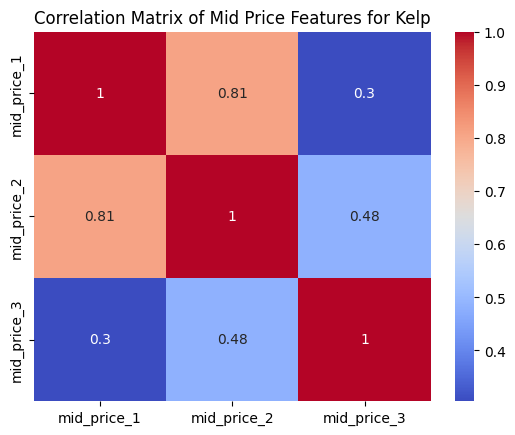

In [4]:
import pandas as pd
import seaborn as sns
# Create a DataFrame combining mid_prices from both sources
df_corr = pd.DataFrame({
    'mid_price_1': k["mid_price"],
    'mid_price_2': k1["mid_price"],
    'mid_price_3': k2["mid_price"],
})

# Drop rows with missing values if timestamps don't match perfectly
df_corr = df_corr.dropna()

# Compute correlation matrix
correlation_matrix = df_corr.corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Mid Price Features for Kelp")
plt.show()


# Data Loading SQUID INK



/var/folders/cf/56rkkkts0hn_0lmp9_4p59dm0000gn/T/ipykernel_53027/2224633060.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  si['smoothed'] = si['mid_price'].rolling(window=300).mean()
/var/folders/cf/56rkkkts0hn_0lmp9_4p59dm0000gn/T/ipykernel_53027/2224633060.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  si2['smoothed'] = si2['mid_price'].rolling(window=300).mean()
/var/folders/cf/56rkkkts0hn_0lmp9_4p59dm0000gn/T/ipykernel_53027/2224633060.py:16: SettingWithCopyWarning: 
A value is trying to be 

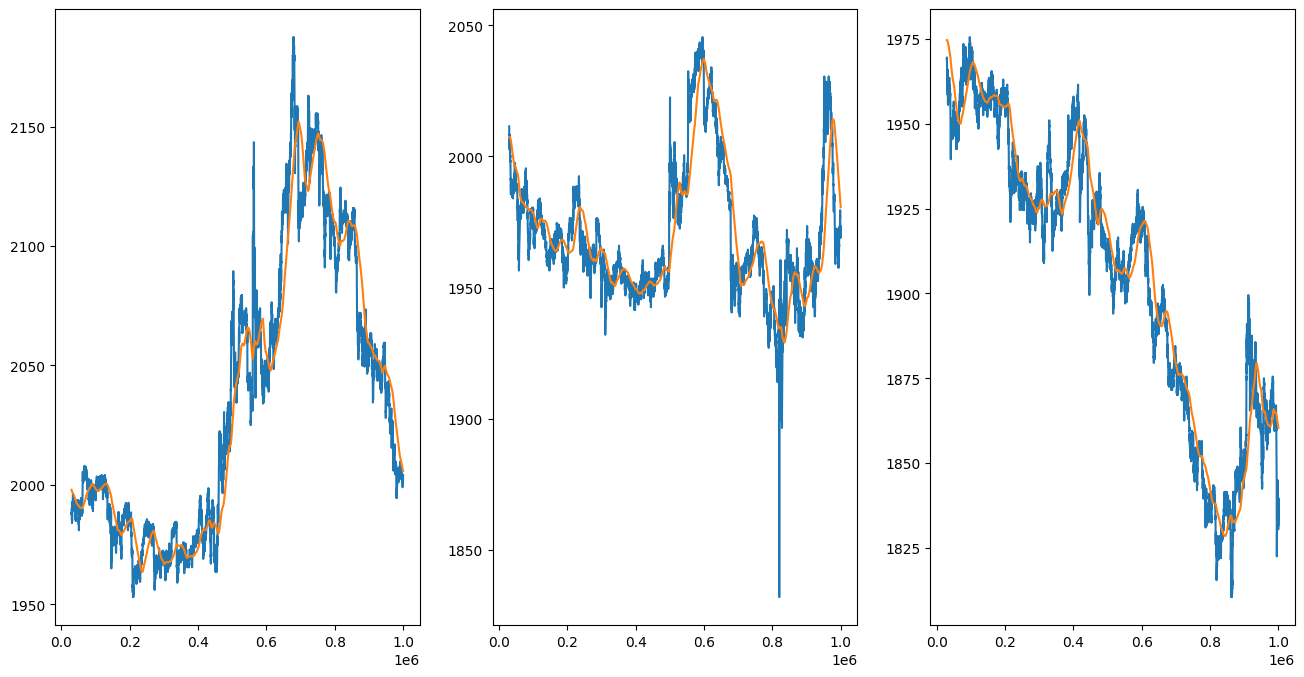

In [5]:
d1 = pd.read_csv("data/prices_round_1_day_-2.csv" , delimiter=";")
d2 = pd.read_csv("data/prices_round_1_day_-1.csv" , delimiter=";")
d3 = pd.read_csv("data/prices_round_1_day_0.csv" , delimiter=";")





si =d1[d1["product"] == "SQUID_INK"]
si['smoothed'] = si['mid_price'].rolling(window=300).mean()

si2 =d2[d2["product"] == "SQUID_INK"]
si2['smoothed'] = si2['mid_price'].rolling(window=300).mean()

si3 =d3[d3["product"] == "SQUID_INK"]
si3['smoothed'] = si3['mid_price'].rolling(window=300).mean()


si = si.dropna(subset=['smoothed'])
si2 = si2.dropna(subset=['smoothed'])
si3 = si3.dropna(subset=['smoothed'])
import math
fig, axes = plt.subplots(1, 3, figsize=(16, 8))


axes[0].plot(si["timestamp"],si["mid_price"])
axes[0].plot(si["timestamp"],si["smoothed"])

axes[1].plot(si["timestamp"],si2["mid_price"])
axes[1].plot(si["timestamp"],si2["smoothed"])
axes[2].plot(si["timestamp"],si3["mid_price"])
axes[2].plot(si["timestamp"],si3["smoothed"])







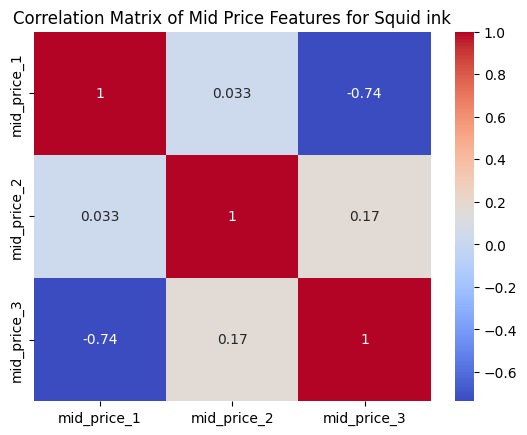

In [6]:
import pandas as pd
import seaborn as sns

df_corr = pd.DataFrame({
    'mid_price_1': si["mid_price"],
    'mid_price_2': si2["mid_price"],
    'mid_price_3': si3["mid_price"],
})

df_corr = df_corr.dropna()

correlation_matrix = df_corr.corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Mid Price Features for Squid ink")
plt.show()

In [7]:
from statsmodels.tsa.stattools import adfuller

diffsi = si["mid_price"].diff().dropna()
res = adfuller(diffsi)
print(res)


from statsmodels.tsa.stattools import adfuller
import numpy as np
import pandas as pd

np.random.seed(0)

from arch.unitroot import ADF

test = ADF(diffsi)
print(test.summary())
print("p-value:", test.pvalue)

(-15.907637851826642, 8.192349187932481e-29, 30, 9669, {'1%': -3.4310264956989713, '5%': -2.8618389697303326, '10%': -2.566929136468723}, 39472.50748325408)
   Augmented Dickey-Fuller Results   
Test Statistic                -15.908
P-value                         0.000
Lags                               30
-------------------------------------

Trend: Constant
Critical Values: -3.43 (1%), -2.86 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.
p-value: 8.192349187932481e-29


# Data Loading RESIN



/var/folders/cf/56rkkkts0hn_0lmp9_4p59dm0000gn/T/ipykernel_53027/952604728.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rr['smoothed'] = rr['mid_price'].rolling(window=400).mean()
/var/folders/cf/56rkkkts0hn_0lmp9_4p59dm0000gn/T/ipykernel_53027/952604728.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rr2['smoothed'] = rr2['mid_price'].rolling(window=400).mean()
/var/folders/cf/56rkkkts0hn_0lmp9_4p59dm0000gn/T/ipykernel_53027/952604728.py:9: SettingWithCopyWarning: 
A value is trying to be set on

   Augmented Dickey-Fuller Results   
Test Statistic                -27.724
P-value                         0.000
Lags                               37
-------------------------------------

Trend: Constant
Critical Values: -3.43 (1%), -2.86 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.
p-value: 0.0


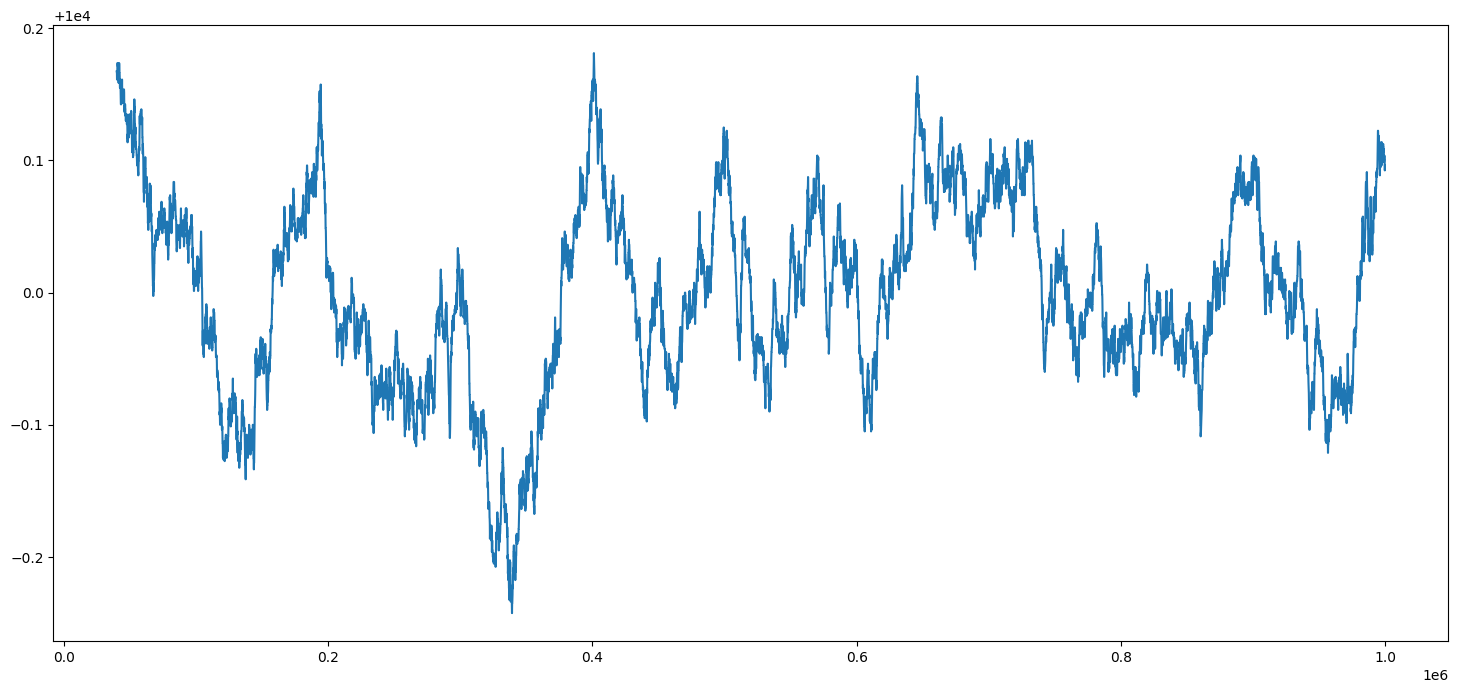

In [8]:
d1 = pd.read_csv("data/prices_round_1_day_-2.csv" , delimiter=";")
d2 = pd.read_csv("data/prices_round_1_day_-1.csv" , delimiter=";")
d3 = pd.read_csv("data/prices_round_1_day_0.csv" , delimiter=";")
rr =d1[d1["product"] == "RAINFOREST_RESIN"]
rr2 =d2[d2["product"] == "RAINFOREST_RESIN"]
rr3 =d3[d3["product"] == "RAINFOREST_RESIN"]
rr['smoothed'] = rr['mid_price'].rolling(window=400).mean()
rr2['smoothed'] = rr2['mid_price'].rolling(window=400).mean()
rr3['smoothed'] = rr3['mid_price'].rolling(window=400).mean()
rr = rr.dropna(subset=['smoothed'])
rr2 = rr2.dropna(subset=['smoothed'])
rr3 = rr3.dropna(subset=['smoothed'])

import math
plt.figure(figsize=(18, 8))
plt.plot(rr["timestamp"],rr["smoothed"])

from arch.unitroot import ADF

test = ADF(rr3["mid_price"].diff().dropna())
print(test.summary())
print("p-value:", test.pvalue)


# Analysing mean reversion of RESIN



count    4728.000000
mean        1.930415
std         1.298818
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        12.000000
Name: since_last_zero, dtype: float64
(9601, 18)


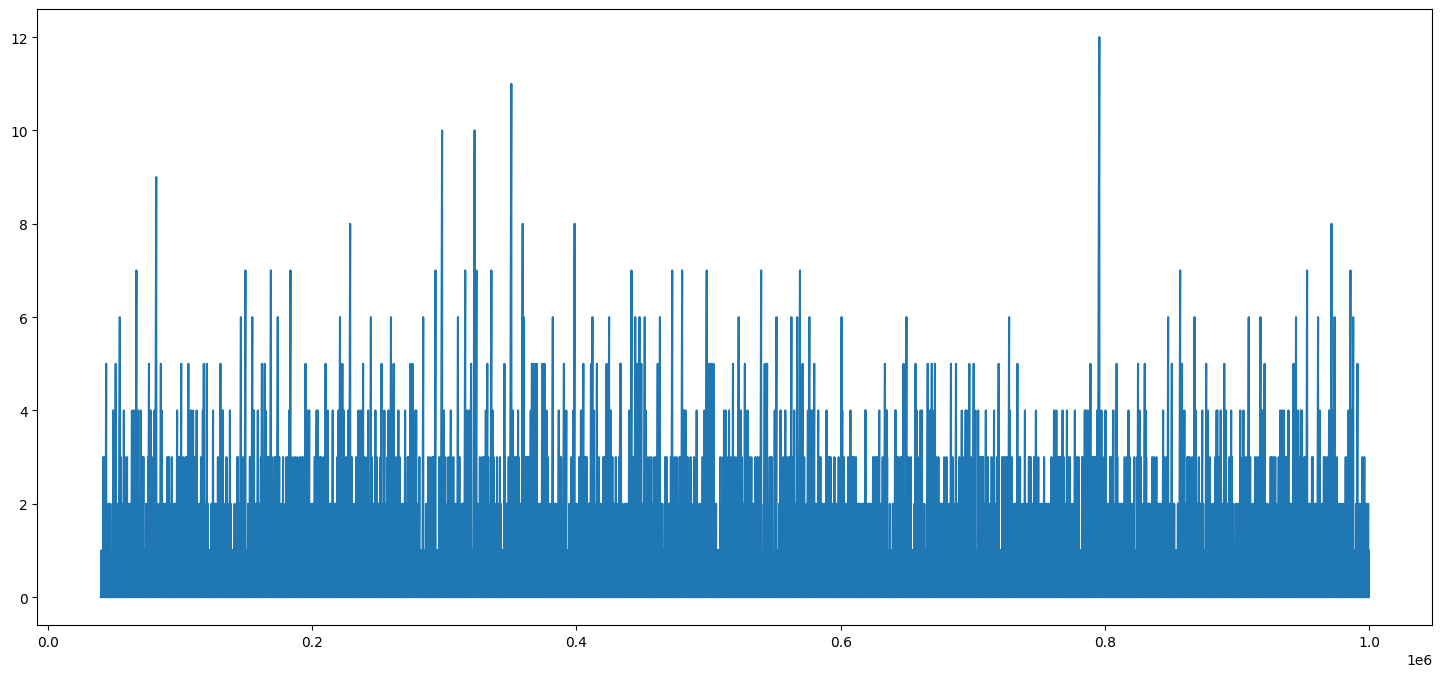

In [9]:
import math
plt.figure(figsize=(18, 8))
zeromast = rr["mid_price"] == 10000.0
zergr = zeromast.cumsum()
tslz = zergr.groupby(zergr).cumcount()
tsz = pd.DataFrame({'value': rr["mid_price"], 'since_last_zero': tslz})
tszch = tsz[tsz['since_last_zero'] != 0]

print(tszch["since_last_zero"].describe())
print(rr.shape)
plt.plot(rr["timestamp"],tsz["since_last_zero"])

In [10]:
merged_df = pd.merge(rr, si, on='timestamp')
merged_df2 = pd.merge(rr2, si2, on='timestamp')
merged_df3 = pd.merge(rr3, si3, on='timestamp')


mmdf = pd.merge(k, rr, on='timestamp')
mmdf2 = pd.merge(k1, rr2, on='timestamp')
mmdf3 = pd.merge(k2, rr3, on='timestamp')




## Squid Ink and kelp  and Resin Price Relationship

Here we visualize the relationship between Squid Ink and Resin prices across 3 days of merged data. The left plot shows the difference between smoothed price signals (Squid Ink - Resin), revealing a pattern that can be exploited for trading. The right plot displays the smoothed Resin prices for comparison. We discovered that these two products have a symmetrical relationship with respect to a horizontal line, allowing us to use Resin as a reference signal for predicting Squid Ink price movements.






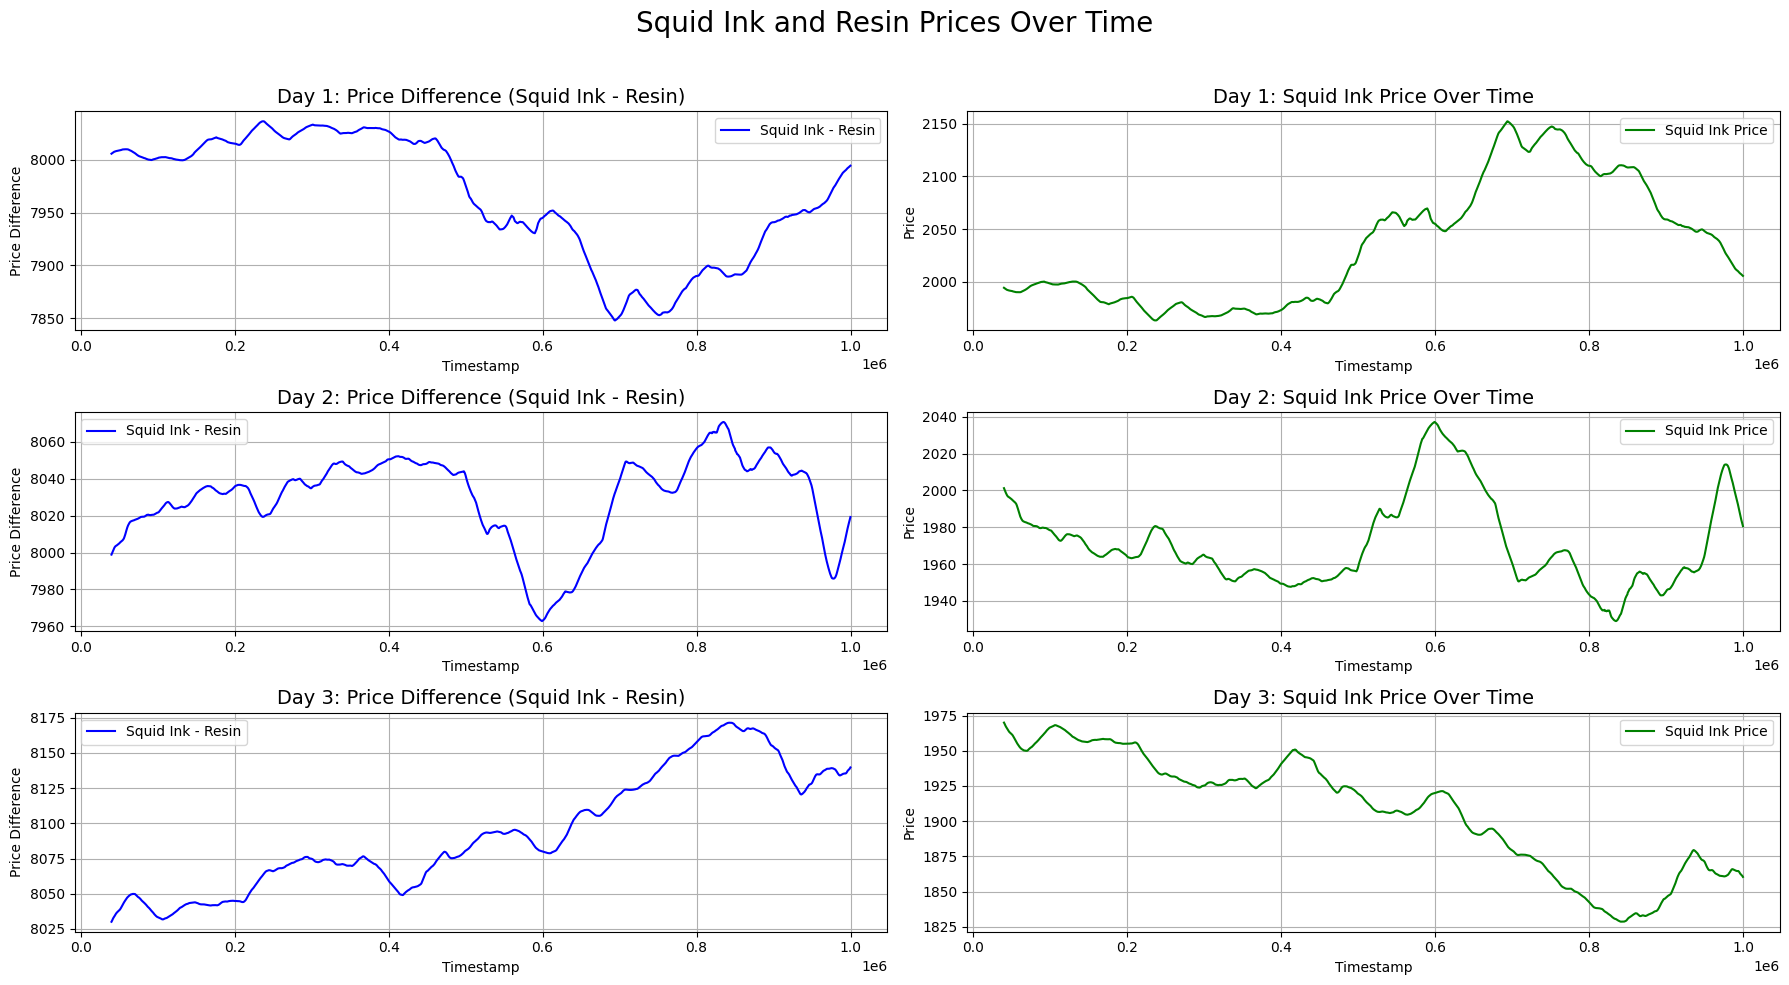

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 2, figsize=(18, 10))
fig.suptitle("Squid Ink and Resin Prices Over Time", fontsize=20)

datasets = [(merged_df, 'Day 1'), (merged_df2, 'Day 2'), (merged_df3, 'Day 3')]

for i, (df, label) in enumerate(datasets):
    axes[i][0].plot(df["timestamp"], df["smoothed_x"] - df["smoothed_y"], color='blue', label='Squid Ink - Resin')
    axes[i][0].set_title(f'{label}: Price Difference (Squid Ink - Resin)', fontsize=14)
    axes[i][0].set_xlabel('Timestamp')
    axes[i][0].set_ylabel('Price Difference')
    axes[i][0].legend()
    axes[i][0].grid(True)
    
    axes[i][1].plot(df["timestamp"], df["smoothed_y"], color='green', label='Squid Ink Price')
    axes[i][1].set_title(f'{label}: Squid Ink Price Over Time', fontsize=14)
    axes[i][1].set_xlabel('Timestamp')
    axes[i][1].set_ylabel('Price')
    axes[i][1].legend()
    axes[i][1].grid(True)
    


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# for kelp

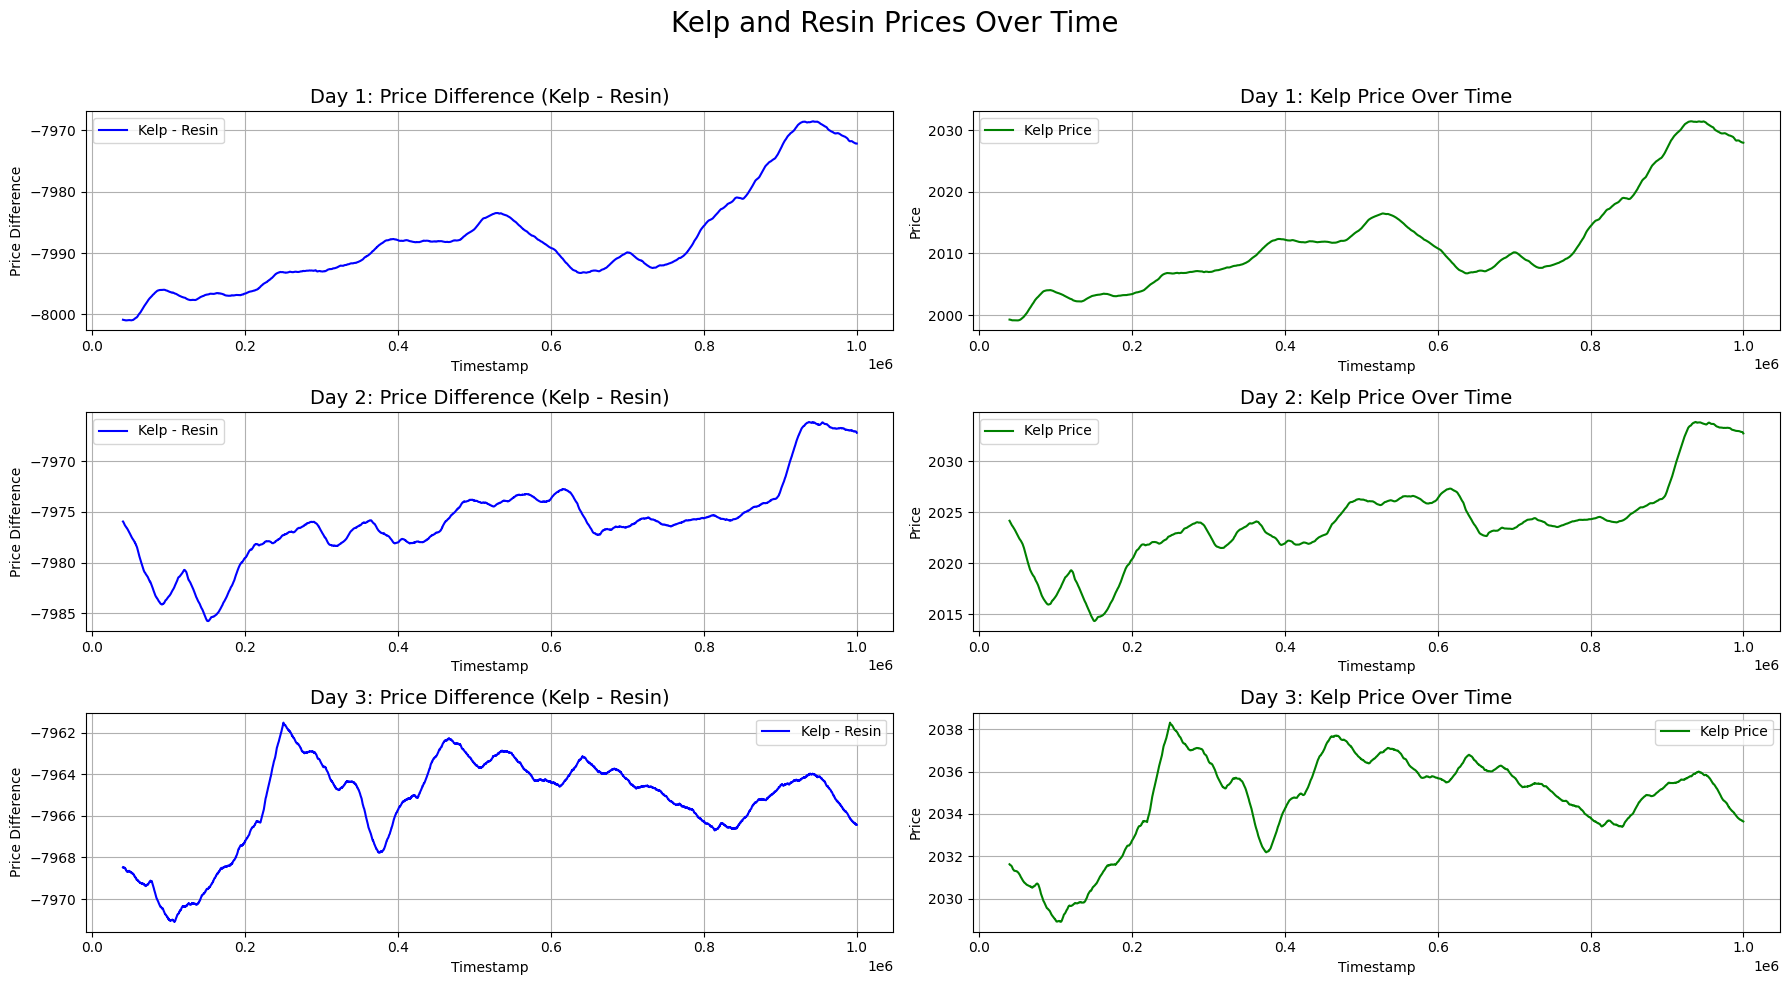

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 2, figsize=(18, 10))
fig.suptitle("Kelp and Resin Prices Over Time", fontsize=20)

datasets = [(mmdf, 'Day 1'), (mmdf2, 'Day 2'), (mmdf3, 'Day 3')]

for i, (df, label) in enumerate(datasets):
    axes[i][0].plot(df["timestamp"], df["smoothed_x"] - df["smoothed_y"], color='blue', label='Kelp - Resin')
    axes[i][0].set_title(f'{label}: Price Difference (Kelp - Resin)', fontsize=14)
    axes[i][0].set_xlabel('Timestamp')
    axes[i][0].set_ylabel('Price Difference')
    axes[i][0].legend()
    axes[i][0].grid(True)
    
    axes[i][1].plot(df["timestamp"], df["smoothed_x"], color='green', label='Kelp Price')
    axes[i][1].set_title(f'{label}: Kelp Price Over Time', fontsize=14)
    axes[i][1].set_xlabel('Timestamp')
    axes[i][1].set_ylabel('Price')
    axes[i][1].legend()
    axes[i][1].grid(True)
    


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

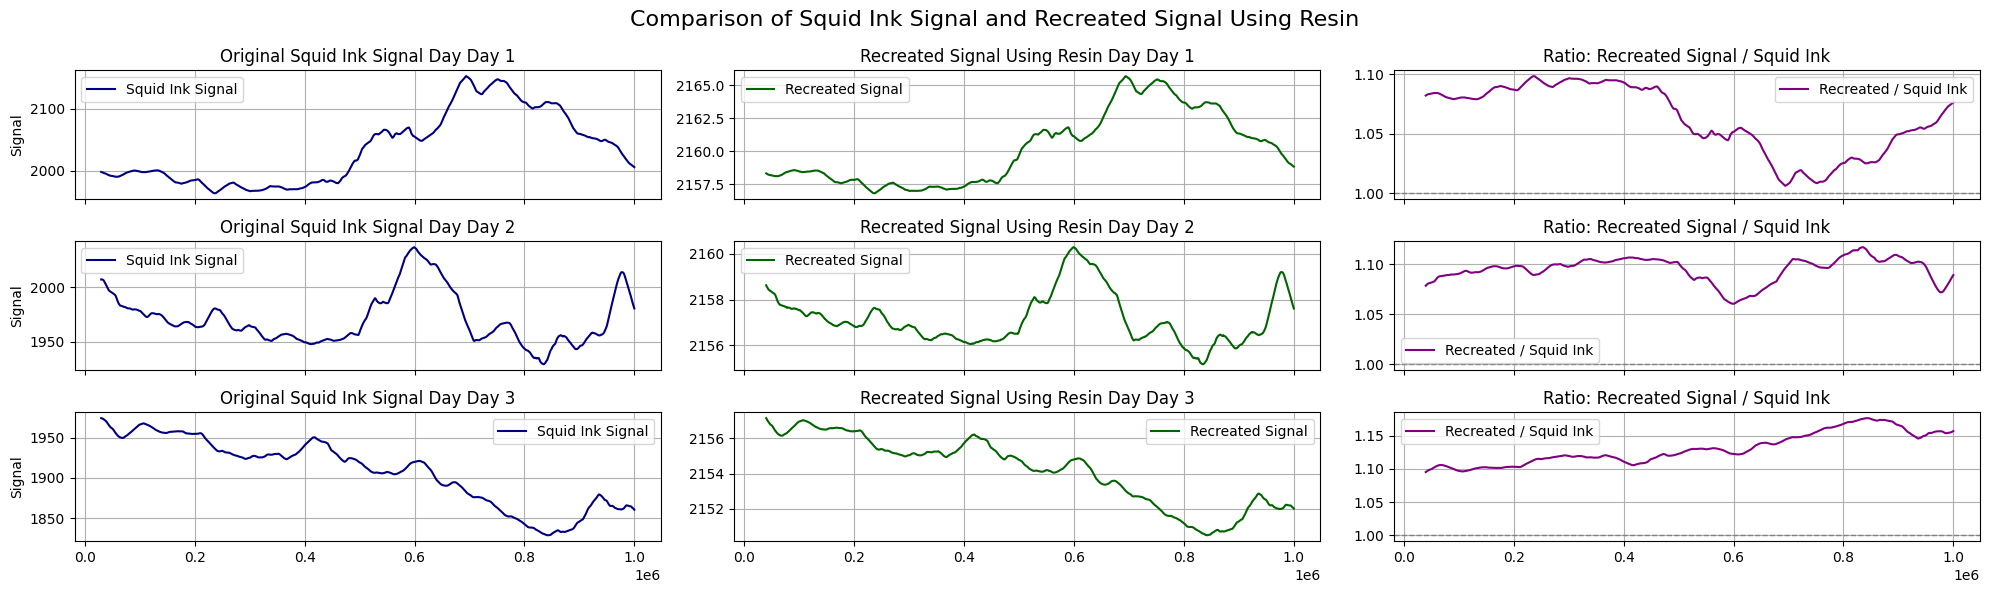

In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 3, figsize=(20, 6), sharex=True)

for ax in axes:
    for i in range(3):
        ax[i].grid(True)

datasets = [(merged_df, 'Day 1'), (merged_df2, 'Day 2'), (merged_df3, 'Day 3')]
sqd = [(si, 'Day 1'), (si2, 'Day 2'), (si3, 'Day 3')]
    
for i in range(3):


    axes[i][0].plot(sqd[i][0]["timestamp"], sqd[i][0]["smoothed"], color="navy", label="Squid Ink Signal")
    axes[i][0].set_title(f"Original Squid Ink Signal Day {sqd[i][1]}")
    axes[i][0].set_ylabel("Signal")
    axes[i][0].legend()
    

    recreated_signal = (datasets[i][0]["smoothed_x"] - (-datasets[i][0]["smoothed_y"] + 4.2 * 1900) / 5.2) / 4.1
    axes[i][1].plot(datasets[i][0]["timestamp"], recreated_signal, color="darkgreen", label="Recreated Signal")
    axes[i][1].set_title(f"Recreated Signal Using Resin Day {datasets[i][1]}")
    axes[i][1].legend()

    from scipy.interpolate import interp1d
    import numpy as np

    interp_squid = interp1d(sqd[i][0]["timestamp"], sqd[i][0]["smoothed"], bounds_error=False, fill_value="extrapolate")
    squid_on_resin_time = interp_squid(merged_df3["timestamp"])
    ratio = recreated_signal / squid_on_resin_time

    axes[i][2].plot(datasets[i][0]["timestamp"], ratio, color="purple", label="Recreated / Squid Ink")
    axes[i][2].set_title("Ratio: Recreated Signal / Squid Ink")
    axes[i][2].axhline(1, color='gray', linestyle='--', linewidth=1)
    axes[i][2].legend()



plt.suptitle("Comparison of Squid Ink Signal and Recreated Signal Using Resin", fontsize=16)
plt.tight_layout()
plt.show()


### Conclusion

The resin signal exhibits a strong **mean-reversion characteristic**, which makes it well-suited for implementing a **market-making strategy**.

Furthermore, the **consistent relationship between the Squid Ink and Resin signals** suggests that Resin can be used as a **predictive proxy to trade Squid Ink**. Similarly, this relationship holds between Kelp and Resin, allowing for potential cross-asset trading strategies leveraging signal correlations.
